In [1]:
import torch
import torch.nn as nn
import numpy as np
class ConcatBlockConv5(nn.Module):
    def __init__(self, in_ch, out_ch, k=32, act=nn.SiLU):
        super().__init__()
        
        def make_block(kernel_size):
            return nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding='same'),
                nn.BatchNorm1d(out_ch),
                act()
            )

        self.c1 = make_block(k)          # k=32
        self.c2 = make_block(k * 2)      # k=64
        self.c3 = make_block(k // 2)     # k=16
        self.c4 = make_block(k // 4)     # k=8
        self.c5 = make_block(k * 4)      # k=128
        
        c6_in_channels = (out_ch * 5) + in_ch
        
        self.c6 = nn.Sequential(
            nn.Conv1d(c6_in_channels, out_ch, kernel_size=1),
            nn.BatchNorm1d(out_ch),
            act()
        )

    def forward(self, x):
        x1 = self.c1(x)
        x2 = self.c2(x)
        x3 = self.c3(x)
        x4 = self.c4(x)
        x5 = self.c5(x)

        out = torch.cat([x1, x2, x3, x4, x5, x], dim=1)
        
        return self.c6(out)

In [2]:
class GWNet(nn.Module):
    def __init__(self, channels=3, classes=1):
        super().__init__()

        self.b1 = ConcatBlockConv5(channels, 32, k=32)
        self.p1 = nn.MaxPool1d(2)

        self.b2 = ConcatBlockConv5(32, 64, k=32)
        self.p2 = nn.MaxPool1d(2)

        self.b3 = ConcatBlockConv5(64, 128, k=32)
        self.p3 = nn.MaxPool1d(2)

        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, classes)

    def forward(self, x):
        x = self.p1(self.b1(x))
        x = self.p2(self.b2(x))
        x = self.p3(self.b3(x))
        x = self.gap(x).squeeze(-1)
        return self.fc(x)

In [3]:
def read_file(fname):
    data = np.load(fname)
    return data

from scipy import signal
from scipy.signal.windows import tukey
sos = signal.butter(8, [20, 500], btype="bandpass", output="sos", fs=2048)
def bandpass(x):
    for i in range(3):
        x[i] = signal.sosfilt(sos, x[i])
    return x

scaling = [1.5e-20, 1.5e-20, 0.5e-20]
def preprocess(data):
    p1, p2, p3 = bandpass(data)
    p1 = p1 / scaling[0]
    p2 = p2 / scaling[1]
    p3 = p3 / scaling[2]
    return p1, p2, p3

def load_and_preprocess(file_path):
    data = read_file(file_path)
    p1, p2, p3 = preprocess(data)
    stacked = np.stack([p1, p2, p3], axis=0)
    return stacked

def get_model_probability(processed_data):
    input_tensor = torch.tensor(processed_data).float()
    input_tensor = input_tensor.unsqueeze(0)
    device = next(model.parameters()).device
    input_tensor = input_tensor.to(device)
    with torch.no_grad():
        outputs = model(input_tensor)
        prob = torch.sigmoid(outputs).item()
    return prob

In [4]:
model = GWNet()
checkpoint_path = "residual_model_least_process_final.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=torch.device('cpu')))
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Model loaded successfully via state_dict!")

Model loaded successfully via state_dict!


/tmp/ipykernel_6112/3767076434.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=torch.device('cpu')))


In [32]:
data = load_and_preprocess("00000e74ad.npy")

In [33]:
prob = get_model_probability(data)

In [34]:
print(prob)

0.5093114972114563


In [31]:
def wave_model(t, A, omega, phase):
    return A * np.sin(omega * t + phase)
    
def load_and_preprocess(file_path):
    data = read_file(file_path)
    p1, p2, p3 = preprocess(data)
    stacked = np.stack([p1, p2, p3], axis=0)
    return stacked

def get_model_probability(processed_data):
    input_tensor = torch.tensor(processed_data).float()
    input_tensor = input_tensor.unsqueeze(0)
    device = next(model.parameters()).device
    input_tensor = input_tensor.to(device)
    with torch.no_grad():
        outputs = model(input_tensor)
        prob = torch.sigmoid(outputs).item()
    return prob
    
import numpy as np
from scipy.optimize import curve_fit

def get_initial_guesses(t_segment, y_segment):
    # 1. Estimate Amplitude (Standard Deviation * sqrt(2) is a good proxy for Sine Amp)
    guess_A = 1#np.std(y_segment) * np.sqrt(2)

    # 2. Estimate Frequency using FFT (Fast Fourier Transform)
    spectrum = np.fft.fft(y_segment)
    frequencies = np.fft.fftfreq(len(y_segment), d=(t_segment[1]-t_segment[0]))
    
    positive_freqs = frequencies[:len(frequencies)//2]
    positive_spectrum = np.abs(spectrum[:len(spectrum)//2])
    
    # Find the peak frequency
    peak_freq_index = np.argmax(positive_spectrum)
    peak_freq_hz = positive_freqs[peak_freq_index]
    
    # Convert to Angular Frequency (Omega)
    guess_omega = 2 * np.pi * peak_freq_hz
    
    # If FFT returns 0 (DC offset), force a fallback to LIGO's (100Hz)
    if guess_omega < 10.0: 
        guess_omega = 628.0 # Fallback to ~100 Hz

    return [guess_A, guess_omega, 0.0]

In [35]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error
from tqdm.notebook import tqdm  # Specialized progress bar for Jupyter
import os

# --- PHYSICS CONSTANTS ---
FS = 2048.0                       # Sampling Rate (Hz)
DURATION = 2.0                    # Duration (seconds)
N_POINTS = 4096                   # Number of data points
TIME_VECTOR = np.linspace(0, DURATION, N_POINTS)
DETECTORS = ['H1', 'L1', 'V1']    # Hanford, Livingston, Virgo

In [36]:
results = []
for i in range(3):
    y_raw = data[i]
    try:
        p0 = get_initial_guesses(TIME_VECTOR, y_raw)

        params, pcov = curve_fit(wave_model, TIME_VECTOR, y_raw, p0=p0, 
                      bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]), maxfev=5000)

        results.append(params)
    except (RuntimeError, ValueError):
        pass

In [37]:
print(prob)

0.5093114972114563


In [38]:
print(results)

[array([8.76156204e-03, 8.43408211e+01, 2.24047903e+00]), array([ 1.13023958e-02,  8.74911063e+01, -1.28705314e+00]), array([2.44863976e-02, 1.22462622e+02, 2.88176073e+00])]


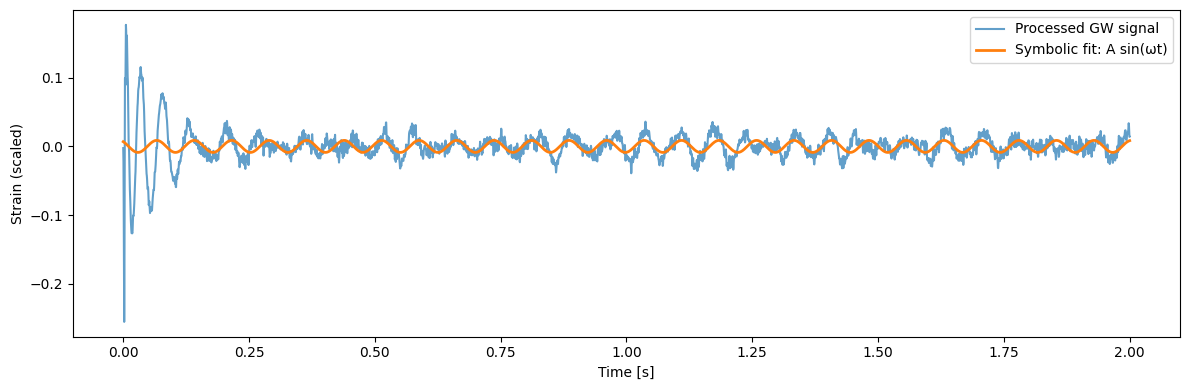

In [42]:
fitted = results[0][0] * np.sin(results[0][1] * TIME_VECTOR + results[0][2])

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(TIME_VECTOR, data[0], label="Processed GW signal", alpha=0.7)
plt.plot(TIME_VECTOR, fitted, label="Symbolic fit: A sin(ωt)", linewidth=2)
plt.xlabel("Time [s]")
plt.ylabel("Strain (scaled)")
plt.legend()
plt.tight_layout()
plt.show()

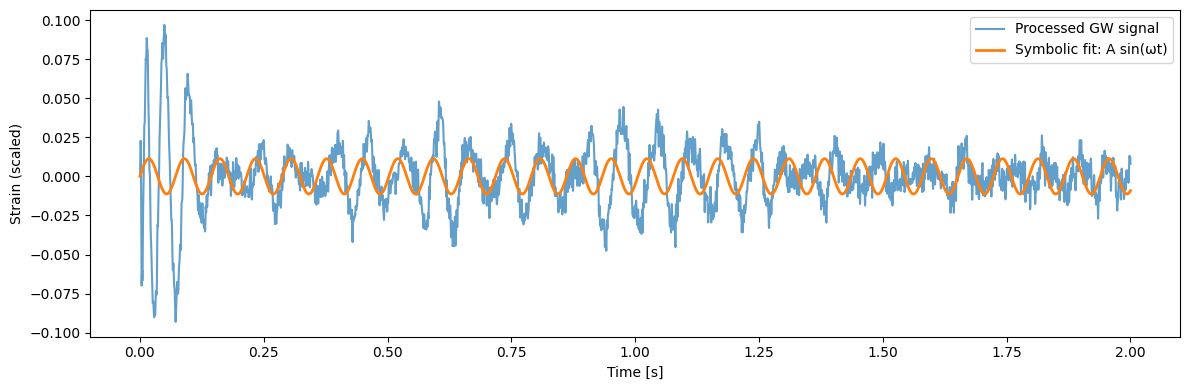

In [29]:
fitted = results[1][0] * np.sin(results[1][1] * TIME_VECTOR + results[1][2])

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(TIME_VECTOR, data[1], label="Processed GW signal", alpha=0.7)
plt.plot(TIME_VECTOR, fitted, label="Symbolic fit: A sin(ωt)", linewidth=2)
plt.xlabel("Time [s]")
plt.ylabel("Strain (scaled)")
plt.legend()
plt.tight_layout()
plt.show()

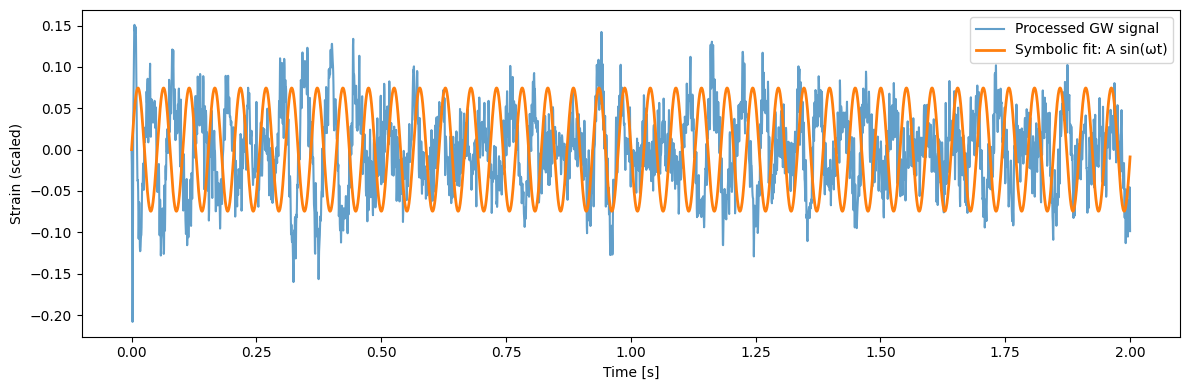

In [41]:
fitted = (results[2][0]+0.05) * np.sin(results[2][1] * TIME_VECTOR + results[2][2])

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(TIME_VECTOR, data[2], label="Processed GW signal", alpha=0.7)
plt.plot(TIME_VECTOR, fitted, label="Symbolic fit: A sin(ωt)", linewidth=2)
plt.xlabel("Time [s]")
plt.ylabel("Strain (scaled)")
plt.legend()
plt.tight_layout()
plt.show()